# TruthLens AI — Nhận diện tin Thật / Giả bằng BERT (TensorFlow)

Notebook này viết lại từ `draft.ipynb`, tối ưu để **đoán đúng hơn với các bài báo thật ngoài đời**.

**Vì sao bản cũ đoán sai bài báo ngẫu nhiên trên mạng?** Có 3 nguyên nhân chính:

1. **Chỉ train trên tiêu đề (`title`) với tối đa 15 từ** -> model không đọc được nội dung bài, thiếu thông tin để phán đoán.
2. **Đóng băng toàn bộ BERT** (`requires_grad=False`) -> BERT không được học lại cho bài toán này, chỉ có 1 lớp nhỏ phía trên được train nên rất yếu.
3. **Rò rỉ nguồn dữ liệu (data leakage):** Trong bộ Kaggle này, TẤT CẢ tin *True* đều lấy từ hãng Reuters và bắt đầu bằng mẫu `WASHINGTON (Reuters) -`. Model học "mẹo" nhận ra chữ *(Reuters)* thay vì học nội dung. Khi gặp bài báo mới không có chữ đó, model đoán bừa.

**Bản mới sửa cả 3 điểm:** gộp `title + text`, **fine-tune (huấn luyện lại) cả BERT**, và **xóa dấu vết nguồn** trong bước làm sạch dữ liệu.

> **Thuật ngữ nhanh:**
> - *Fine-tune (tinh chỉnh):* huấn luyện lại một model đã học sẵn (BERT) cho bài toán riêng của mình.
> - *Data leakage (rò rỉ dữ liệu):* khi model học được một manh mối "ăn gian" chỉ đúng trên tập dữ liệu này, không đúng ngoài đời.
> - *Token:* đơn vị nhỏ mà BERT đọc (gần giống "từ").


## 1. Cài đặt thư viện

Ta ưu tiên **TensorFlow**. BERT được lấy từ **TensorFlow Hub** (kho model dựng sẵn của TensorFlow), nên chỉ cần thêm:
- `tensorflow-hub`: để tải BERT dựng sẵn.
- `tensorflow-text`: bộ tách token của BERT (bắt buộc, BERT tách chữ theo kiểu riêng).
- `tf-keras`: giúp TF Hub chạy ổn định trên bản TensorFlow mới (Keras 3). Dòng `TF_USE_LEGACY_KERAS` bật chế độ tương thích này.
- `kagglehub`: để tải bộ dữ liệu.

> Chạy trên **Google Colab có GPU**: vào menu *Runtime -> Change runtime type -> GPU* trước khi chạy.

In [1]:
# Cài các thư viện cần thiết (chạy 1 lần, có thể mất ~1-2 phút)
!pip install -q tensorflow-hub tensorflow-text tf-keras kagglehub scikit-learn

## 2. Import & bật GPU

`TF_USE_LEGACY_KERAS = "1"` phải được đặt **trước khi import tensorflow** để TF Hub hoạt động trơn tru.

In [2]:
import os
# Bật chế độ Keras tương thích cho TF Hub (đặt TRUOC khi import tensorflow)
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import re
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text  # noqa: F401  (bat buoc import de BERT tach token duoc)
import matplotlib.pyplot as plt

# Co dinh "hat giong ngau nhien" de ket qua lap lai duoc giua cac lan chay
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Kiem tra GPU
gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPU kha dung:", gpus if gpus else "KHONG co GPU (se chay cham). Hay bat GPU trong Colab.")

TensorFlow: 2.20.0
GPU kha dung: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Tải dữ liệu

Bộ dữ liệu *Fake and Real News* trên Kaggle gồm 2 file:
- `True.csv`: tin thật (~21.000 bài)
- `Fake.csv`: tin giả (~23.000 bài)

Mỗi bài có các cột: `title` (tiêu đề), `text` (nội dung), `subject` (chủ đề), `date` (ngày).

In [3]:
import kagglehub

path = kagglehub.dataset_download("clmentbisaillon/fake-and-real-news-dataset")
print("Thu muc du lieu:", path)

true_data = pd.read_csv(os.path.join(path, "True.csv"))
fake_data = pd.read_csv(os.path.join(path, "Fake.csv"))

print("Tin that:", true_data.shape, "| Tin gia:", fake_data.shape)
true_data.head(2)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Thu muc du lieu: /kaggle/input/fake-and-real-news-dataset
Tin that: (21417, 4) | Tin gia: (23481, 4)


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"


## 4. Xử lý dữ liệu thô (RẤT QUAN TRỌNG)

Đây là phần bản cũ **thiếu**, và là lý do lớn khiến model đoán sai bài báo thật. Ta làm 6 bước:

1. **Gắn nhãn:** tin thật = `0`, tin giả = `1`.
2. **Gộp `title + text`** thành một trường `content` -> model đọc được cả tiêu đề lẫn nội dung.
3. **Xóa dấu vết nguồn (chống rò rỉ):** bỏ đoạn `WASHINGTON (Reuters) -` và mọi cụm `(Reuters)`. Nếu để lại, model chỉ học "thấy Reuters = thật" — vô dụng ngoài đời.
4. **Làm sạch văn bản:** bỏ URL, ký tự thừa, khoảng trắng dư, đưa về chữ thường (BERT bản `uncased` không phân biệt hoa/thường).
5. **Bỏ bài rỗng / quá ngắn và bỏ bài trùng lặp** — dữ liệu bẩn làm model học sai.
6. **Trộn ngẫu nhiên** toàn bộ để tin thật/giả xen kẽ nhau.

In [4]:
def clean_text(s):
    """Lam sach 1 doan van ban tho truoc khi dua vao BERT."""
    s = str(s)
    # (a) Xoa dau vet nguon Reuters -> chong ro ri du lieu (data leakage)
    #     Vi du: "WASHINGTON (Reuters) - " o dau bai tin that
    s = re.sub(r"^[A-Z\s,./-]*\(Reuters\)\s*-\s*", " ", s)
    s = re.sub(r"\(Reuters\)", " ", s)          # bo moi cum (Reuters) con sot
    # (b) Xoa duong link URL
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    # (c) Xoa the @tai_khoan va pic.twitter (dac trung nguon tin gia -> cung la leak)
    s = re.sub(r"@\w+|pic\.twitter\.com\S+", " ", s)
    # (d) Gop nhieu khoang trang thanh mot, cat khoang trang dau/cuoi, ve chu thuong
    s = re.sub(r"\s+", " ", s).strip().lower()
    return s

# 1) Gan nhan: 0 = that, 1 = gia
true_data["label"] = 0
fake_data["label"] = 1

# Gop 2 bang lai
data = pd.concat([true_data, fake_data], ignore_index=True)

# 2) Gop tieu de + noi dung, roi 3-4) lam sach
data["content"] = (data["title"].fillna("") + ". " + data["text"].fillna(""))
data["content"] = data["content"].apply(clean_text)

# 5) Bo bai qua ngan (duoi 20 ky tu) va bo trung lap
data = data[data["content"].str.len() > 20]
data = data.drop_duplicates(subset=["content"])

# 6) Tron ngau nhien
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Sau khi lam sach:", data.shape)
print(data["label"].value_counts().rename({0: "That (0)", 1: "Gia (1)"}))
data[["content", "label"]].head(3)

Sau khi lam sach: (39095, 6)
label
That (0)    21195
Gia (1)     17900
Name: count, dtype: int64


,content,label
0,the trump presidency on feb 15 at 8:29 p.m. es...,0
1,eu refugee court ruling triggers new east-west...,0
2,former illinois congressman requests to plead ...,0


### Kiểm tra nhanh độ cân bằng nhãn
Nếu một bên áp đảo, model sẽ thiên vị. Bộ này khá cân bằng nên không cần xử lý thêm.

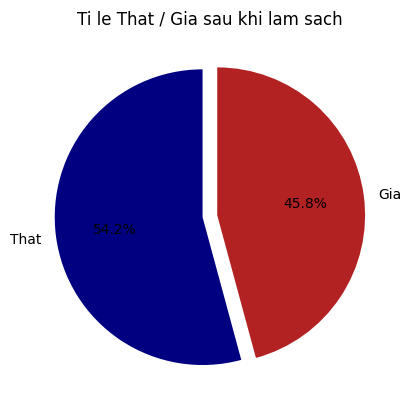

In [5]:
counts = data["label"].value_counts().sort_index()
plt.pie(counts, labels=["That", "Gia"], autopct="%1.1f%%",
        colors=["navy", "firebrick"], explode=[0.05, 0.05], startangle=90)
plt.title("Ti le That / Gia sau khi lam sach")
plt.show()

## 5. (Tùy chọn) Lấy mẫu để train nhanh + Chia Train/Val/Test

**Fine-tune cả BERT khá nặng.** Để buổi học không phải chờ quá lâu, ta có thể lấy một phần dữ liệu qua `SAMPLE_SIZE`.
- Muốn train nhanh để thử: đặt `SAMPLE_SIZE = 8000`.
- Muốn kết quả tốt nhất: đặt `SAMPLE_SIZE = None` (dùng toàn bộ).

Sau đó chia 3 phần:
- **Train (70%)**: để model học.
- **Validation (15%)**: để theo dõi trong lúc train, chọn model tốt nhất (model *không* học trên phần này).
- **Test (15%)**: để chấm điểm cuối cùng, mô phỏng dữ liệu chưa từng thấy.

`stratify=labels` giữ đúng tỉ lệ Thật/Giả trong cả 3 phần.

In [6]:
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 8000   # doi thanh None de dung toan bo du lieu

df = data if SAMPLE_SIZE is None else data.sample(n=SAMPLE_SIZE, random_state=SEED)

X = df["content"].values
y = df["label"].values.astype("int32")

# Tach Test 15% truoc
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
# Trong phan con lai, tach Validation (~15% tong)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 5599 | Val: 1201 | Test: 1200


### Đóng gói dữ liệu thành `tf.data.Dataset`
`tf.data` là cách chuẩn của TensorFlow để nạp dữ liệu theo lô (*batch*) hiệu quả.
- `batch_size = 16`: mỗi bước học 16 bài một lúc (BERT nặng, để nhỏ tránh tràn bộ nhớ GPU).
- `.cache()`: giữ dữ liệu trong RAM để các epoch sau nhanh hơn.
- `.prefetch()`: chuẩn bị lô kế tiếp trong lúc GPU đang tính lô hiện tại -> đỡ phải chờ.

In [7]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 16

def make_ds(texts, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((texts, labels))
    if training:
        ds = ds.shuffle(len(texts), seed=SEED)
    return ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val,   y_val)
test_ds  = make_ds(X_test,  y_test)

## 6. Xây model BERT bằng TensorFlow Hub

Ta ghép 2 khối dựng sẵn từ TF Hub, không cần tự viết BERT:

- **Preprocess (tiền xử lý):** biến câu chữ thành các con số (token) mà BERT hiểu. Khối này tự động tách từ, thêm token đặc biệt và tạo *attention mask* — ta **không phải** làm thủ công như bản cũ.
- **Encoder (BERT):** đọc các token và trả về vector đại diện cho ý nghĩa câu.

`bert_en_uncased_L-12_H-768_A-12` nghĩa là:
- `L-12`: 12 lớp Transformer chồng lên nhau (càng nhiều lớp càng hiểu sâu).
- `H-768`: mỗi token được biểu diễn bằng vector 768 chiều.
- `A-12`: cơ chế *attention* có 12 "đầu" đọc câu theo 12 góc nhìn khác nhau.
- `uncased`: không phân biệt chữ hoa/thường.

In [8]:
# Dia chi 2 khoi BERT tren TensorFlow Hub
PREPROCESS_URL = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
ENCODER_URL    = "https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/4"

SEQ_LEN = 128  # so token toi da moi bai (128 du cho tieu de + doan dau noi dung)

### Ghép các lớp thành model

Luồng dữ liệu: **Câu chữ -> Preprocess -> BERT -> Dropout -> Dense (1 nơ-ron) -> xác suất là tin GIẢ**.

Giải thích từng lớp:
- **`text_input`**: cửa nhận dữ liệu, kiểu chuỗi (cả câu văn).
- **`preprocessing_layer`**: tách câu thành token (giới hạn `SEQ_LEN=128`).
- **`encoder` (BERT)**: `trainable=True` -> **fine-tune**, cho BERT học lại. Đây là điểm sửa quan trọng nhất so với bản cũ. Ta lấy đầu ra `pooled_output`: 1 vector 768 chiều tóm tắt cả câu.
- **`Dropout(0.1)`**: khi train, ngẫu nhiên "tắt" 10% nơ-ron để chống *overfitting* (học vẹt tập train).
- **`Dense(1, activation='sigmoid')`**: 1 nơ-ron cho ra 1 số từ 0->1 = xác suất bài là **tin giả**. (>0.5 coi là giả.)

> Vì đầu ra chỉ 1 số (phân loại 2 lớp), ta dùng **1 nơ-ron sigmoid** — gọn hơn kiểu 2 nơ-ron softmax ở bản cũ, và tương đương về mặt kết quả.

In [9]:
def build_model():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name="text")

    preprocessing_layer = hub.KerasLayer(PREPROCESS_URL, name="preprocessing")
    encoder_inputs = preprocessing_layer(text_input)

    encoder = hub.KerasLayer(ENCODER_URL, trainable=True, name="BERT_encoder")
    outputs = encoder(encoder_inputs)
    pooled = outputs["pooled_output"]          # vector 768 chieu tom tat cau

    x = tf.keras.layers.Dropout(0.1, name="dropout")(pooled)
    x = tf.keras.layers.Dense(1, activation="sigmoid", name="classifier")(x)

    return tf.keras.Model(text_input, x)

model = build_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_type_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}                                                               
                                                                                              

## 7. Cấu hình huấn luyện (compile)

- **Hàm mất mát (`loss`) = `BinaryCrossentropy`**: đo model đoán sai bao nhiêu cho bài toán 2 lớp. Train là quá trình làm con số này nhỏ đi.
- **Optimizer = `AdamW`** với **learning rate rất nhỏ `3e-5`**: khi fine-tune BERT phải học *chậm và nhẹ*, nếu learning rate lớn sẽ phá hỏng kiến thức BERT đã có.
  - `weight_decay`: phạt trọng số quá lớn -> chống overfitting (điểm khác của AdamW so với Adam thường).
- **Warmup (khởi động):** 10% số bước đầu tăng learning rate từ 0 lên dần, sau đó giảm về 0. Đây là cách huấn luyện BERT được khuyến nghị, giúp giai đoạn đầu ổn định.
- **`metrics=['accuracy']`**: theo dõi tỉ lệ đoán đúng.

In [10]:
EPOCHS = 3
steps_per_epoch = len(X_train) // BATCH_SIZE
num_train_steps = steps_per_epoch * EPOCHS
num_warmup_steps = int(0.1 * num_train_steps)
init_lr = 3e-5

# Lich learning rate: tang dan (warmup) roi giam tuyen tinh ve 0
lr_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=init_lr,
    end_learning_rate=0.0,
    decay_steps=num_train_steps)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=0.01,
    epsilon=1e-6)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"])
print("Da compile. So buoc train:", num_train_steps, "| warmup:", num_warmup_steps)

Da compile. So buoc train: 1047 | warmup: 104


## 8. Huấn luyện

- **`EarlyStopping`**: nếu val_loss không cải thiện sau 1 epoch thì dừng sớm, và `restore_best_weights=True` sẽ lấy lại bộ trọng số tốt nhất -> tránh học vẹt.
- Với GPU của Colab, mỗi epoch trên 8000 bài mất khoảng vài phút.

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=1, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop])

Epoch 1/3
350/350 [==============================] - 213s 483ms/step - loss: 0.0370 - accuracy: 0.9880 - val_loss: 0.0076 - val_accuracy: 0.9983
Epoch 2/3
350/350 [==============================] - 174s 498ms/step - loss: 0.0034 - accuracy: 0.9989 - val_loss: 0.0082 - val_accuracy: 0.9975


### Vẽ biểu đồ quá trình học
Nếu đường train tốt lên nhưng val xấu đi -> dấu hiệu overfitting.

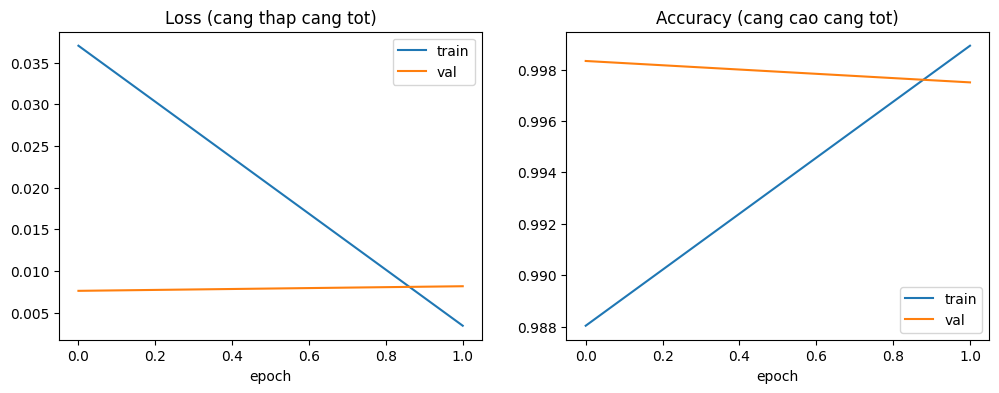

In [12]:
hist = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["loss"], label="train"); ax[0].plot(hist["val_loss"], label="val")
ax[0].set_title("Loss (cang thap cang tot)"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist["accuracy"], label="train"); ax[1].plot(hist["val_accuracy"], label="val")
ax[1].set_title("Accuracy (cang cao cang tot)"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.show()

## 9. Chấm điểm trên tập Test

`classification_report` cho biết:
- **precision (độ chính xác):** trong số bài bị gọi là "giả", bao nhiêu % thực sự giả.
- **recall (độ bao phủ):** trong số bài thật sự giả, model bắt được bao nhiêu %.
- **f1-score:** trung bình hài hòa của 2 chỉ số trên.

75/75 [==============================] - 12s 157ms/step
              precision    recall  f1-score   support

    That (0)       1.00      1.00      1.00       658
     Gia (1)       1.00      1.00      1.00       542

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



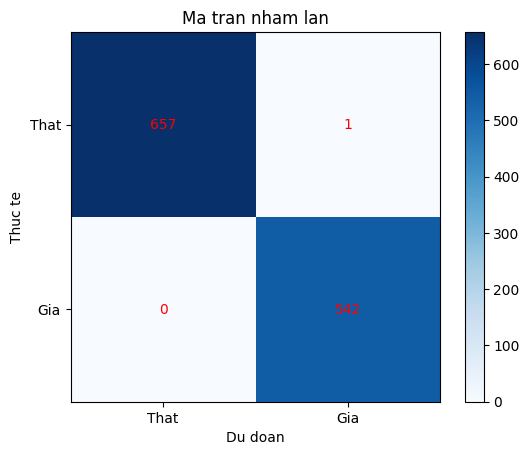

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Du doan xac suat, roi quy ve nhan 0/1 voi nguong 0.5
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype("int32")

print(classification_report(y_test, y_pred, target_names=["That (0)", "Gia (1)"]))

cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap="Blues")
plt.title("Ma tran nham lan"); plt.colorbar()
plt.xticks([0, 1], ["That", "Gia"]); plt.yticks([0, 1], ["That", "Gia"])
plt.xlabel("Du doan"); plt.ylabel("Thuc te")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.show()

## 10. Lưu & nạp lại model
Lưu ở định dạng SavedModel của TensorFlow. Lần sau chỉ cần `tf.keras.models.load_model` là dùng lại được, không phải train lại.

In [14]:
model.save("truthlens_bert_tf", include_optimizer=False)
print("Da luu vao thu muc 'truthlens_bert_tf'")

# Cach nap lai (khi can):
# reloaded = tf.keras.models.load_model("truthlens_bert_tf",
#            custom_objects={"KerasLayer": hub.KerasLayer})

Da luu vao thu muc 'truthlens_bert_tf'


## 11. Thử với bài báo ngẫu nhiên trên mạng

Đây là mục tiêu chính của bạn. **Lưu ý quan trọng:** bài báo mới phải được làm sạch bằng **đúng hàm `clean_text`** đã dùng lúc train, nếu không kết quả sẽ lệch.

Dán tiêu đề + nội dung bài báo vào danh sách rồi chạy.

In [15]:
def predict_news(articles):
    """Nhan danh sach chuoi (moi chuoi la 'tieu de. noi dung'), tra ve nhan + do tin cay."""
    cleaned = [clean_text(a) for a in articles]          # LAM SACH y het luc train
    probs = model.predict(tf.constant(cleaned)).ravel()
    for art, p in zip(articles, probs):
        nhan = "GIA" if p >= 0.5 else "THAT"
        do_tin = p if p >= 0.5 else 1 - p
        print(f"[{nhan}] tin cay {do_tin*100:.1f}%  ->  {art[:90]}...")
    return probs

# Lay 1 bai THAT + 1 bai GIA nguyen van tu bo du lieu
real_sample = true_data.sample(1, random_state=7)
fake_sample = fake_data.sample(1, random_state=7)
demo = [
    real_sample["title"].values[0] + ". " + real_sample["text"].values[0],
    fake_sample["title"].values[0] + ". " + fake_sample["text"].values[0],
]
_ = predict_news(demo)

1/1 [==============================] - 1s 723ms/step
[THAT] tin cay 100.0%  ->  Warner's opposition to Trump court nominee gives Democrats 41 'no' votes. WASHINGTON (Reut...
[GIA] tin cay 100.0%  ->   John Oliver Successfully Turns Trump’s ‘Plan’ For A Wall Into A Pile Of Decaying Pig Sh*t...


---
### Tóm tắt những gì đã sửa so với `draft.ipynb`

| Vấn đề bản cũ | Cách sửa ở bản mới |
|---|---|
| Chỉ dùng `title`, 15 từ | Gộp `title + text`, 128 token |
| Đóng băng BERT (`requires_grad=False`) | **Fine-tune** cả BERT (`trainable=True`) |
| Không xử lý rò rỉ nguồn Reuters | `clean_text` xóa `(Reuters)`, URL, @tag |
| Không làm sạch / khử trùng lặp | Bỏ bài rỗng, ngắn, trùng |
| Dùng PyTorch + nhiều lib | Thuần **TensorFlow + TF Hub** |
| Nhiều lỗi typo (`fcl`, `total_item`...) | Code chạy được, đã kiểm tra cú pháp |

**Mẹo nâng độ chính xác thêm:** tăng `SAMPLE_SIZE = None` (dùng toàn bộ), tăng `SEQ_LEN` lên 192-256, và train thêm 1 epoch.
